In [1]:
import os
import shutil
from pathlib import Path

from pyspark.sql import SparkSession, Row
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, LongType, DateType, IntegerType
from pyspark.sql import Row
from pyspark.sql.functions import expr
from pyspark.sql.functions import *
import time


spark = (
    SparkSession.builder
    .appName("Broadcast Joins")
    .master("local[*]")
    .getOrCreate()
)

sc = spark.sparkContext

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/05 15:11:09 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
rows = (
   sc.parallelize([
       Row(0, "zero"),
       Row(1, "first"),
       Row(2, "second"),
       Row(3, "third"),
   ])
)

In [3]:
rowsSchema = StructType([
    StructField("id", IntegerType()),
    StructField("order", StringType()),
])

In [4]:
# small table
lookupTable = spark.createDataFrame(rows, rowsSchema)

In [5]:
# large table
table = spark.range(1, 70000000) # column is id for spark range

In [6]:
# naive join
joined = table.join(lookupTable, "id")

joined.explain()

t0 = time.time()
joined.show()
print(f"naive count took {time.time() - t0:.2f}s")

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [id#4L, order#1]
   +- SortMergeJoin [id#4L], [cast(id#0 as bigint)], Inner
      :- Sort [id#4L ASC NULLS FIRST], false, 0
      :  +- Exchange hashpartitioning(id#4L, 200), ENSURE_REQUIREMENTS, [plan_id=22]
      :     +- Range (1, 70000000, step=1, splits=32)
      +- Sort [cast(id#0 as bigint) ASC NULLS FIRST], false, 0
         +- Exchange hashpartitioning(cast(id#0 as bigint), 200), ENSURE_REQUIREMENTS, [plan_id=21]
            +- Filter isnotnull(id#0)
               +- Scan ExistingRDD[id#0,order#1]




+---+------+
| id| order|
+---+------+
|  1| first|
|  3| third|
|  2|second|
+---+------+

naive count took 4.90s


26/04/05 15:11:23 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


In [7]:
# one data frame is bytes and other is half a gigabyte
# this is several levels of magnitude difference
# for both we have to hash parition and sort which is expensive for the half gig

In [8]:
# smarter join
joinedSmart = table.join(broadcast(lookupTable), "id") 


joinedSmart.explain()

t0 = time.time()
joinedSmart.show()
print(f"smart join count took {time.time() - t0:.2f}s")

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [id#4L, order#1]
   +- BroadcastHashJoin [id#4L], [cast(id#0 as bigint)], Inner, BuildRight, false
      :- Range (1, 70000000, step=1, splits=32)
      +- BroadcastExchange HashedRelationBroadcastMode(List(cast(input[0, int, false] as bigint)),false), [plan_id=156]
         +- Filter isnotnull(id#0)
            +- Scan ExistingRDD[id#0,order#1]


+---+------+
| id| order|
+---+------+
|  1| first|
|  2|second|
|  3| third|
+---+------+

smart join count took 0.51s


We went from 4.5 seconds to 0.5 seconds with broad cast join!

No exchanges or shuffles needed ! 
Broadcast join the small dataframe gets copied to all executors
All joins done in memory, Tiny overhead

if we look at the query plan we see BroadcastExchange - even though it says exchange its not a shuffle it just exchanges data from exectuors.
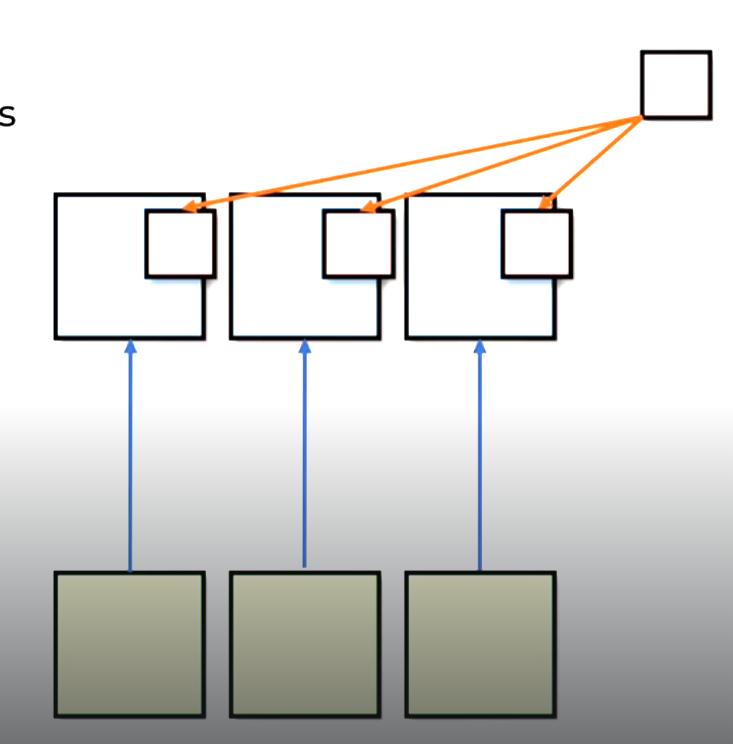

In [9]:
# auto broadcast
bigTable = spark.range(1, 70000000) # column is id for spark range
smallTable = spark.range(1, 10000)

joinedNumbers = bigTable.join(smallTable, "id")

joinedNumbers.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [id#28L]
   +- BroadcastHashJoin [id#28L], [id#30L], Inner, BuildRight, false
      :- Range (1, 70000000, step=1, splits=32)
      +- BroadcastExchange HashedRelationBroadcastMode(List(input[0, bigint, false]),false), [plan_id=231]
         +- Range (1, 10000, step=1, splits=32)




Spark optimizer will automatically broadcast if it detects small tables compared to big tables. Even if tables were swapped and we saw small table joined with big table.


Spark has automatic size estimator by size
You can change the spark autoBroacast threshold with

```
spark.conf.set("spark.sql.autoBroadcastJoinThreshold, 30)
```

the following changes it to 30 bytes to auto broadcast and thus it wont work for the above, can also set it to -1 to disable

Auto broadcast did not show in naive because the createDataFrame has no reliable stats on size but spark.range does have exact stats when you create it

Often when spark reads from parquet catalyst has enough size information from files themselves so auto-broadcast has a much better chance of triggering